# Introduction to pointcloud & Deepset

Pipeline based on Sanmay Ganguly  tutorial on deep sets: https://github.com/sanmayphy/ICTS_ML_SCHOOL/tree/main

In [15]:
# importing the relevant functions
import torch#, torchvision, torchmetrics
import torch.utils.data as data
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
import numpy as np
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [34]:
if(torch.backends.cuda.is_built()) : 
    device='cuda'
elif(torch.backends.mps.is_built()) : 
    device='mps'
else : 
    device='cpu'

### 1. Introduction of the data set, converting it into a costum set based dataset

In [35]:
transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.,), (1.0,)) # mean 0 std 1.
        ])

dataset = datasets.MNIST('./data', train=True, download=True,transform=transform)
dataset # access dataset[image numebr] [0:image, 1:which numebr as a lable]

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.0,), std=(1.0,))
           )

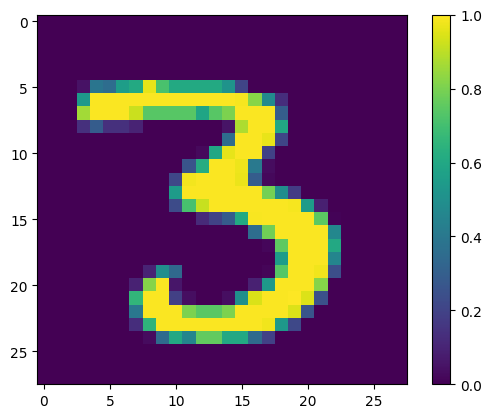

In [56]:
X,y = dataset[12]
img_array = X[0] # because X has the shape torch.Size([1, 28, 28]), we only want the [28, 28]
plt.imshow(X[0].numpy())
plt.colorbar()

In [68]:
#Our goal is to first convert the images into the set of point cloud for non-zero elements, basically as scatter plots.
# this can be acheaved by the line bellow:
coordinates_of_non_zero_example=torch.argwhere(img_array > 0.)[:,:]/img_array.shape[0] # we also devide it by 28 (size) to the coordinate be between 0-1.
coordinates_of_non_zero_example[0:5] # example of coordinates [x,y]



tensor([[0.1786, 0.1071],
        [0.1786, 0.1429],
        [0.1786, 0.1786],
        [0.1786, 0.2143],
        [0.1786, 0.2500]])

In [9]:
# def transform_2d_img_to_point_cloud(data):
    
#     img, label = data
#     img_array = img[0]
#     values = img_array[img_array > 0]
#     x_coord = torch.argwhere(img_array > 0.)[:,0]/img_array.shape[0]
#     y_coord = torch.argwhere(img_array > 0.)[:,1]/img_array.shape[0]
    
#     return torch.stack( (x_coord, y_coord, values), dim=-1), label 
#vect = transform_2d_img_to_point_cloudT(X)

In [71]:
# here we want to define a costum fuction and dataset class, the point is this gets the tensors of input dataset, and convert them to set based dataset

# this is a child class of data.Dataset. basically has some mofificatgions
class MNISTPC_Dataset(data.Dataset):

    def __init__(self, dataset_path:str, train:bool = True, download:bool =False, mean:float = 0., std:float = 1.) -> None:
        """
        Inputs:
            size - Number of data points we want to generate
            std - Standard deviation of the noise (see generate_continuous_xor function)
        """
        super().__init__()

        #__ just the normalization of data
        self.transform = transforms.Compose(
                       [
                        transforms.ToTensor(),
                        transforms.Normalize((mean,), (std,))
                       ]
                       )

        # the data set is downloaded insied the class
        self.dataset = datasets.MNIST(dataset_path, train=train, download=download,
                       transform=self.transform)
        

        # this will conver points to clpouds, will be defined later
        self.pc_dataset = [ self.transform_2d_img_to_point_cloud(self.dataset[idx]) for idx in range(len(self.dataset)) ]


    
    def transform_2d_img_to_point_cloud(self, data_i:tuple) -> dict : #data_i:tuple is  tuple because the data has also the lables. (only for labaled data.)
    
        img, label = data_i # here we unwrap the tuple
        img_array = img[0] # convertin shape from 3d to 2d.
        values = img_array[img_array > 0]
        
        x_coord = torch.argwhere(img_array > 0.)[:,0]/img_array.shape[0] # x locations
        y_coord = torch.argwhere(img_array > 0.)[:,1]/img_array.shape[0] # y locations
        
        point_vec = torch.stack( (x_coord, y_coord, values), dim=-1) # combines x y and pixel value into one tuple.
        
        return {'point' : point_vec, 'label' : label, 'seq_length' : len(point_vec)}

    
    # the Datasewt class there should always be __len__ and  __getitem__ fuctions. 
    
    def __len__(self) -> int:
        # Number of data point we have. Alternatively self.data.shape[0], or self.label.shape[0]
        return len(self.pc_dataset)
    
    def __getitem__(self, idx:int) -> dict :
        # Return the idx-th data point of the dataset
    
        return self.pc_dataset[idx]#data_point, data_label


In [72]:
# now we can run and make a point cloud datqaset: pc_dataset
pc_dataset = MNISTPC_Dataset('./data/')

In [83]:
len(pc_dataset)

60000

In [77]:
pc_dataset[19] # {point: (x,y, value), label: , length:}

{'point': tensor([[0.2500, 0.4643, 0.0706],
         [0.2500, 0.5000, 0.4118],
         [0.2500, 0.5357, 0.8902],
         [0.2500, 0.5714, 0.9922],
         [0.2500, 0.6071, 0.9922],
         [0.2500, 0.6429, 0.4784],
         [0.2857, 0.4286, 0.2235],
         [0.2857, 0.4643, 0.7804],
         [0.2857, 0.5000, 0.9922],
         [0.2857, 0.5357, 0.9882],
         [0.2857, 0.5714, 0.9882],
         [0.2857, 0.6071, 0.9882],
         [0.2857, 0.6429, 0.9882],
         [0.2857, 0.6786, 0.6235],
         [0.3214, 0.3929, 0.0784],
         [0.3214, 0.4286, 0.8275],
         [0.3214, 0.4643, 0.9882],
         [0.3214, 0.5000, 0.9098],
         [0.3214, 0.5357, 0.5961],
         [0.3214, 0.5714, 0.2863],
         [0.3214, 0.6071, 0.6549],
         [0.3214, 0.6429, 0.9882],
         [0.3214, 0.6786, 0.8431],
         [0.3214, 0.7143, 0.0235],
         [0.3571, 0.3929, 0.7725],
         [0.3571, 0.4286, 0.9882],
         [0.3571, 0.4643, 0.7137],
         [0.3571, 0.6071, 0.1451],
         [0

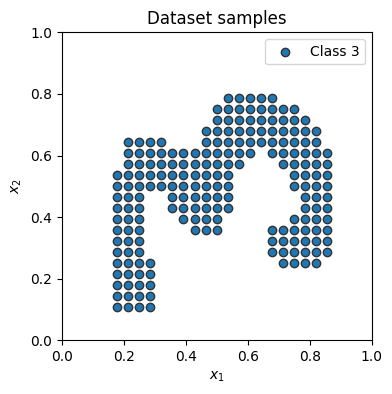

In [94]:
# converts point cloud data into a plot:
def visualize_samples(data, label, marker='o'):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()
        
    plt.figure(figsize=(4,4))
    plt.scatter(data[:,0] , data[:,1], edgecolor="#333", marker=marker, label="Class " + str(label))
    
    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.legend()

index=12
pc, label = pc_dataset[index]['point'], pc_dataset[index]['label']
visualize_samples(pc, label)

### 2. Define the mini batches for training

In [95]:
# Important:: Zero padding: when we have sequences with different legths (our point cloud siezes for each image), 
#we should do zero padding by finding the max length of all sets and then filling the rest of the data with zeros. 
# after creating the padded full batch we will be able to pass it to Data loader

def create_batch(data_list : list) -> tuple : 
    
    max_length = np.max([data_list[idx]['seq_length'] for idx in range(len(data_list))  ]) # finding the max legth of the set
    
    pc_list, label_list = [], [] 
    
    for idx in range(len(data_list)) : 
        
        pc, label = data_list[idx]['point'], data_list[idx]['label']
        
        N, C = pc.shape[0], pc.shape[1]
        
        pc_padded = torch.zeros([1, max_length, C]) 
        
        pc = pc.reshape(1, N, C) # (N, C) -> (1, N, C)
        
        pc_padded[:, 0 : N, :   ] = pc[:,:,:] # add the actual points, and the rest will be zeros.
        
        pc_list.append(pc_padded)
        label_list.append( torch.tensor([label]) )
    

    return torch.cat(pc_list, dim=0), torch.cat(label_list, dim=0)

In [96]:
type(pc_dataset)

__main__.MNISTPC_Dataset

In [101]:
pc_dataloader = data.DataLoader(dataset=pc_dataset, batch_size=5, shuffle=True, collate_fn=create_batch)

pc_chunk, label_chunk = next(iter(pc_dataloader))

pc_chunk.shape, label_chunk.shape

(torch.Size([5, 258, 3]), torch.Size([5]))

## 3. Define the basic deepset layer

A permutation equivariant layer is defined as 
$$ 
x' = \Theta. x \equiv \gamma \mathbb{I}.x + \lambda (\mathbb{I} \mathbb{I}^T) . x~~~\lambda \,, \gamma \in \mathbb{R}
$$ 

Assuming $x = (x_1, x_2, x_3)^T$, the above equation becomes : 
$$
\begin{pmatrix}
x_1' \\
x_2' \\
x_3' 
\end{pmatrix}
= \gamma 
\begin{pmatrix}
1 && 0 && 0 \\
0 && 1 && 0 \\
0 && 0 && 1
\end{pmatrix} 
\begin{pmatrix}
x_1 \\
x_2 \\
x_3 
\end{pmatrix} + 
\lambda
\begin{pmatrix}
1 && 1 && 1 \\
1 && 1 && 1 \\
1 && 1 && 1
\end{pmatrix}  
\begin{pmatrix}
x_1 \\
x_2 \\
x_3 
\end{pmatrix} \\ \\
= 
\begin{pmatrix}
(\gamma + \lambda)x_1 + \lambda(x_2 + x_3)\\
(\gamma + \lambda)x_2 + \lambda(x_1 + x_3) \\
(\gamma + \lambda)x_3 + \lambda(x_1 + x_2) 
\end{pmatrix} \\ \\
= (\gamma + \lambda)
\begin{pmatrix}
x_1 \\
x_2 \\
x_3 
\end{pmatrix}
- \lambda
\begin{pmatrix}
x_1 - \sum x_i\\
x_2 - \sum x_i\\
x_3 - \sum x_i
\end{pmatrix}
= \Gamma .x + \Lambda.\Big(x - \alpha(x) \Big)
$$


In [221]:
class DeepSet_Linear_Layer(nn.Module):
    def __init__(self, in_features:int, out_features:int,  normalization:str = '', pool:str = 'mean') -> None :
        """
        DeepSets single layer
        :param in_features: input's number of features
        :param out_features: output's number of features
        :param attention: Whether to use attention
        :param normalization: normalization method - 'fro' or 'batchnorm'
        
        """
        super(DeepSet_Linear_Layer, self).__init__()

        self.Gamma = nn.Linear(in_features, out_features) # linear is [multiplication and bias]
        self.Lambda = nn.Linear(in_features, out_features)

        self.normalization = normalization
        self.pool = pool
        
        if normalization == 'batchnorm':
            self.bn = nn.BatchNorm1d(out_features)

    def forward(self, x : torch.Tensor) -> torch.Tensor :
        # x.shape = (B, N, C),  x is a minimbatch. B: batch size, N:numebr of points in that set ,C:dimenssion of fatures

        # difference between mean and max is the choice of permiation invariant a(x)
        if(self.pool == 'mean') : 
            x = self.Gamma(x) + self.Lambda(x-x.mean(dim=1, keepdim=True)) # -- the average is over the points -- #
            
        elif(self.pool == 'max') :
            x = self.Gamma(x) + self.Lambda(x-x.max(dim=1, keepdim=True)) # -- the max is over the points -- #

        # normalization
        if self.normalization == 'batchnorm':
            x = self.bn(x)
        
        return x

In [222]:
ds_layer = DeepSet_Linear_Layer(in_features = 3, out_features = 4)

In [223]:
y = ds_layer(pc_chunk)

In [224]:
pc_chunk.shape, y.shape

(torch.Size([5, 258, 3]), torch.Size([5, 258, 4]))

## 4 Make the full deepset model as stack of Deepset layers and non-linear activation functions

In [241]:
class DeepSet(nn.Module):
    def __init__(self, in_features:int, feats:list, n_class:int, normalization:str = '', pool:str = 'mean') ->None:
        """
        DeepSets architecture for set classification.

        Input:
            x ∈ R^{B × N × C}
                B : batch size
                N : number of elements in the set
                C : feature dimension per element

        The network follows the DeepSets structure:

            X → g(X) (permutation equivariant network)
              → pooling (permutation invariant)
              → classifier ρ

        where g(X) is implemented by stacking equivariant layers.

        Parameters
        ----------
        in_features : int
            Dimensionality of each element in the input set.

        feats : list[int]
            Hidden feature sizes for the stacked equivariant layers.
            Example: [64,128,256]

        n_class : int
            Number of output classes.

        normalization : str
            Optional normalization method ('batchnorm' or '').

        pool : str
            Permutation-invariant aggregation used inside the equivariant layer
            (e.g. 'mean' or 'max').
            
        """
        super(DeepSet, self).__init__()

        layers = []

        # ------------------------------------------------------------------
        # First equivariant linear layer
        #
        # Implements the transformation
        #
        #   y_i = Γ x_i + Λ a(X)
        #
        # where a(X) is a permutation-invariant summary of the set
        # (e.g. mean or max across elements).
        #
        # This preserves permutation equivariance.
        # ------------------------------------------------------------------
        layers.append(DeepSet_Linear_Layer(in_features = in_features, out_features = feats[0], normalization = normalization, pool = pool))


        
        # ------------------------------------------------------------------
        # Stack multiple equivariant blocks
        #
        # Each block consists of:
        #
        #   equivariant linear layer
        #   followed by a pointwise non-linearity
        #
        # Nonlinearities (ReLU here) are applied element-wise, so
        # permutation equivariance is preserved.
        # ------------------------------------------------------------------
        
        for i in range(1, len(feats)):
            layers.append(nn.ReLU())
            layers.append(DeepSet_Linear_Layer(in_features = feats[i-1], out_features = feats[i], normalization = normalization, pool = pool))

        # ------------------------------------------------------------------
        # Final equivariant layer producing per-element class logits
        #
        # Each element now produces a vector of size n_class.
        # The final set prediction will be obtained after pooling.
        # ------------------------------------------------------------------
        layers.append(DeepSet_Linear_Layer(in_features = feats[-1], out_features = n_class, normalization = normalization, pool = pool))
        #self.sequential = nn.Sequential(*layers)

        # Using ModuleList instead of Sequential because the forward pass
        # is applied manually in a loop.
        self.sequential = nn.ModuleList(layers)

    # Pass input through stacked equivariant layers
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        #return self.sequential(x)
        for i, layer in enumerate(self.sequential):
            x = layer(x)

        
        #------------------------------------------------------------------
        # Permutation-invariant pooling across elements
        #
        # This collapses the set dimension:
        #
        #   z = mean_i x_i
        #
        # resulting in a single vector per set.
        # ------------------------------------------------------------------
        x = x.mean(dim=1) # -- average over the points -- #
        out = F.log_softmax(x, dim=-1)
        
        return out
                

In [242]:
model = DeepSet(in_features=3, feats=[5, 9, 12, 16, 13], n_class=10)
model = model.to(device)

In [243]:
y = model(pc_chunk.to(device))

In [244]:
y.shape, label_chunk.shape

(torch.Size([5, 10]), torch.Size([5]))

In [245]:
F.nll_loss(input=y, target=label_chunk.to(device))

tensor(2.3243, device='cuda:0', grad_fn=<NllLossBackward0>)

In [246]:
torch.backends.mps.is_built()

False

In [247]:
device

'cuda'

## 5 creating the training block

In [248]:
def train(model, device, train_loader, optimizer):
    
    train_loss_ep = 0.
    
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss_ep += loss.item() * data.size(0)
        
    return train_loss_ep



## create the testing block

In [249]:
def test(model, device, test_loader):
    
    test_loss_ep = 0.
    
    model.eval()
    for batch_idx, (data, target) in enumerate(test_loader):
        data, target = data.to(device), target.to(device)
         
        output = model(data)
        loss = F.nll_loss(output, target)
        
        test_loss_ep += loss.item() * data.size(0)
        
    return test_loss_ep

# 5 Let's prepare the full dataset and dataloaders

In [250]:
# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 5
# percentage of training set to use as validation
valid_size = 0.2
# # convert data to torch.FloatTensor
# transform = transforms.ToTensor()
# choose the training and testing datasets
train_data =  MNISTPC_Dataset('./data/', train = True, download = True)
test_data = MNISTPC_Dataset('./data/', train = False, download = True)
# obtain training indices that will be used for validation
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_index, valid_index = indices[split:], indices[:split]
# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_index)
valid_sampler = SubsetRandomSampler(valid_index)
# prepare data loaders
train_loader = data.DataLoader(dataset=train_data, batch_size = batch_size, 
                                           num_workers = num_workers, sampler = train_sampler, collate_fn=create_batch)
valid_loader = data.DataLoader(train_data, batch_size = batch_size,
                                          num_workers = num_workers,  sampler = valid_sampler, collate_fn=create_batch)
test_loader = data.DataLoader(test_data, batch_size = batch_size,
                                                     num_workers = num_workers, shuffle=False, collate_fn=create_batch)


In [251]:
model = model.to(device=device)

In [252]:
optimizer = torch.optim.SGD(model.parameters(),lr = 0.01)

## 6 Run the training loop 

In [253]:
# number of epochs to train the model
n_epochs = 20
# initialize tracker for minimum validation loss
valid_loss_min = np.Inf  # set initial "min" to infinity
for epoch in range(n_epochs):
    # monitor losses
    
    train_loss = train(model, device, train_loader, optimizer)
    
    valid_loss = test(model, device, valid_loader)
    
    # print training/validation statistics 
    # calculate average loss over an epoch
    train_loss = train_loss / len(train_loader.sampler)
    valid_loss = valid_loss / len(valid_loader.sampler)
    
    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch+1, 
        train_loss,
        valid_loss
        ))
    
    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model.state_dict(), 'model.pt')
        valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 2.300915 	Validation Loss: 2.289467
Validation loss decreased (inf --> 2.289467).  Saving model ...
Epoch: 2 	Training Loss: 2.101628 	Validation Loss: 2.064781
Validation loss decreased (2.289467 --> 2.064781).  Saving model ...
Epoch: 3 	Training Loss: 2.054337 	Validation Loss: 2.049056
Validation loss decreased (2.064781 --> 2.049056).  Saving model ...
Epoch: 4 	Training Loss: 2.022188 	Validation Loss: 1.986913
Validation loss decreased (2.049056 --> 1.986913).  Saving model ...
Epoch: 5 	Training Loss: 1.967906 	Validation Loss: 1.901858
Validation loss decreased (1.986913 --> 1.901858).  Saving model ...
Epoch: 6 	Training Loss: 1.819522 	Validation Loss: 1.634821
Validation loss decreased (1.901858 --> 1.634821).  Saving model ...
Epoch: 7 	Training Loss: 1.561044 	Validation Loss: 1.388724
Validation loss decreased (1.634821 --> 1.388724).  Saving model ...
Epoch: 8 	Training Loss: 1.193205 	Validation Loss: 0.863629
Validation loss decreased (1.38872

## Load the best saved model and use it for test performance

In [254]:
model_test = DeepSet(in_features=3, feats=[5, 9, 12, 16, 13], n_class=10)
model_test.load_state_dict(torch.load('model.pt'))
model_test.to(device)



DeepSet(
  (sequential): ModuleList(
    (0): DeepSet_Linear_Layer(
      (Gamma): Linear(in_features=3, out_features=5, bias=True)
      (Lambda): Linear(in_features=3, out_features=5, bias=True)
    )
    (1): ReLU()
    (2): DeepSet_Linear_Layer(
      (Gamma): Linear(in_features=5, out_features=9, bias=True)
      (Lambda): Linear(in_features=5, out_features=9, bias=True)
    )
    (3): ReLU()
    (4): DeepSet_Linear_Layer(
      (Gamma): Linear(in_features=9, out_features=12, bias=True)
      (Lambda): Linear(in_features=9, out_features=12, bias=True)
    )
    (5): ReLU()
    (6): DeepSet_Linear_Layer(
      (Gamma): Linear(in_features=12, out_features=16, bias=True)
      (Lambda): Linear(in_features=12, out_features=16, bias=True)
    )
    (7): ReLU()
    (8): DeepSet_Linear_Layer(
      (Gamma): Linear(in_features=16, out_features=13, bias=True)
      (Lambda): Linear(in_features=16, out_features=13, bias=True)
    )
    (9): DeepSet_Linear_Layer(
      (Gamma): Linear(in_fea

In [255]:

def eval_model(model, data_loader):
    model.eval() # Set model to eval mode
    true_preds, num_preds = 0., 0.
    
    with torch.no_grad(): # Deactivate gradients for the following code
        for data_inputs, data_labels in data_loader:
            
            # Determine prediction of model on dev set
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            preds = model(data_inputs)
            # preds = preds.squeeze(dim=1)
            # preds = torch.sigmoid(preds) # Sigmoid to map predictions between 0 and 1
            pred_labels = torch.argmax(preds, dim=-1) # Binarize predictions to 0 and 10
            
            # Keep records of predictions for the accuracy metric (true_preds=TP+TN, num_preds=TP+TN+FP+FN)
            true_preds += (pred_labels == data_labels).sum()
            num_preds += data_labels.shape[0]
            
    acc = true_preds / num_preds
    print(f"Accuracy of the model: {100.0*acc:4.2f}%")

In [257]:
eval_model(model_test, test_loader)

Accuracy of the model: 92.21%


In [53]:
# for child in model.children():
#    print(" child : ",child)

## 7 now looking at the latent represetation of numbers?

In [263]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


@torch.no_grad()
def collect_all_sets_z(model, loader, device):
    """
    Perform a full forward pass through the model and extract the latent
    representation z for every set.

    In your architecture:

        x shape: (B, N, C)

            B = batch size
            N = number of elements in the set
            C = feature dimension per element

    After the final equivariant layer:

        h shape: (B, N, n_class)

    Then you do:

        z = mean_i h_i

    which gives one vector per set:

        z shape: (B, n_class)

    This is the vector that goes into log_softmax in your model.
    """

    model.eval()  # switch model to evaluation mode

    Z_chunks = []  # will store latent vectors z
    y_chunks = []  # will store corresponding labels

    for x, y in loader:

        # move batch to device (CPU or GPU)
        x = x.to(device)

        # ---------------------------------------------------------
        # Forward pass through the equivariant layers
        #
        # We manually reproduce the forward pass from your model
        # but stop BEFORE log_softmax so we can extract z.
        # ---------------------------------------------------------

        h = x  # start with the input

        for layer in model.sequential:
            h = layer(h)

        # Now:
        # h shape = (B, N, n_class)

        # ---------------------------------------------------------
        # Permutation-invariant pooling across set elements
        #
        # This collapses the N dimension and produces one vector
        # per set.
        # ---------------------------------------------------------

        z = h.mean(dim=1)  # shape = (B, n_class)

        # move results back to CPU and store them
        Z_chunks.append(z.cpu())
        y_chunks.append(y.cpu())

    # ---------------------------------------------------------
    # Concatenate all batches together
    # ---------------------------------------------------------

    Z = torch.cat(Z_chunks, dim=0).numpy()  # shape = (num_sets, n_class)
    y = torch.cat(y_chunks, dim=0).numpy()  # shape = (num_sets,)

    return Z, y


def pca_and_highlight_digits(Z, y):
    """
    Perform PCA on the collected latent vectors and visualize them.

    Steps:
    1. Fit PCA globally on ALL sets.
    2. Project each set representation into 2D.
    3. Plot everything in gray.
    4. Overlay points belonging to each digit in a different color.
    """

    # ---------------------------------------------------------
    # Compute PCA
    #
    # This finds the 2 directions of maximum variance in the
    # latent space.
    # ---------------------------------------------------------

    pca = PCA(n_components=2)
    Z2 = pca.fit_transform(Z)

    # Z2 shape = (num_sets, 2)

    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------

    plt.figure()

    # First plot all points as faint background
    plt.scatter(Z2[:, 0], Z2[:, 1], s=8, alpha=0.15)

    # Then highlight each digit separately
    for digit in range(10):

        # find indices of sets belonging to this digit
        idx = (y == digit)

        # overlay them in color
        plt.scatter(
            Z2[idx, 0],
            Z2[idx, 1],
            s=15,
            alpha=0.9,
            label=str(digit)
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA of DeepSets latent space (z)")
    plt.legend(title="digit")
    plt.tight_layout()
    plt.show()

    # print useful diagnostic info
    print("Latent dimension (z):", Z.shape[1])
    print("PCA explained variance ratio:", pca.explained_variance_ratio_)


def umap_and_highlight_digits(Z, y, n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42):
    """
    Perform a non-linear embedding of the latent vectors Z using UMAP
    and visualize the result while highlighting each digit.

    Parameters
    ----------
    Z : np.ndarray
        Latent vectors of shape (num_sets, latent_dim)

    y : np.ndarray
        Labels of shape (num_sets,)

    n_neighbors : int
        Controls how much local neighborhood structure UMAP preserves.
        Smaller = more local clustering, larger = more global structure.

    min_dist : float
        Controls how tightly points are packed in the low-dimensional map.
        Smaller = tighter clusters.

    metric : str
        Distance metric used by UMAP.

    random_state : int
        Random seed for reproducibility.
    """

    # UMAP is not part of sklearn; it usually comes from umap-learn
    try:
        import umap.umap_ as umap
    except ImportError:
        raise ImportError(
            "UMAP is not installed. Install it with:\n"
            "pip install umap-learn"
        )

    # ---------------------------------------------------------
    # Fit UMAP globally on ALL latent vectors
    #
    # This gives a 2D non-linear embedding of the full latent space.
    # ---------------------------------------------------------
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state
    )

    Z2 = reducer.fit_transform(Z)   # shape = (num_sets, 2)

    # ---------------------------------------------------------
    # Plot all points faintly in the background
    # Then overlay each digit separately
    # ---------------------------------------------------------
    plt.figure()

    # background cloud of all sets
    plt.scatter(Z2[:, 0], Z2[:, 1], s=8, alpha=0.12)

    # highlight each label on top
    for digit in range(10):
        idx = (y == digit)
        if np.any(idx):
            plt.scatter(
                Z2[idx, 0],
                Z2[idx, 1],
                s=15,
                alpha=0.9,
                label=str(digit)
            )

    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title("UMAP of DeepSets latent space (z)")
    plt.legend(title="digit")
    plt.tight_layout()
    plt.show()
    

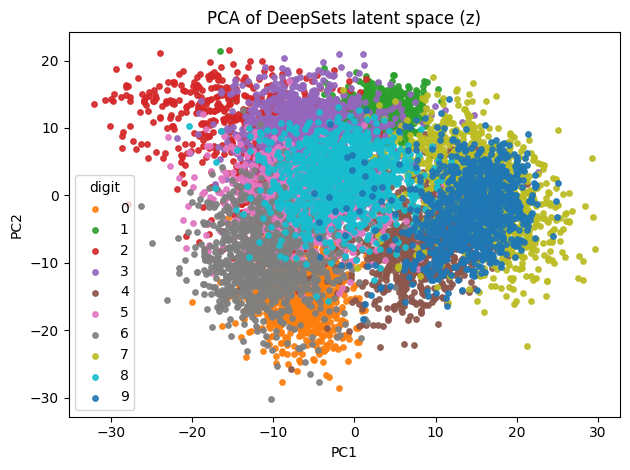

Latent dimension (z): 10
PCA explained variance ratio: [0.37634185 0.30068684]


/home/tiamheydari/anaconda3/envs/nn/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/tiamheydari/anaconda3/envs/nn/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


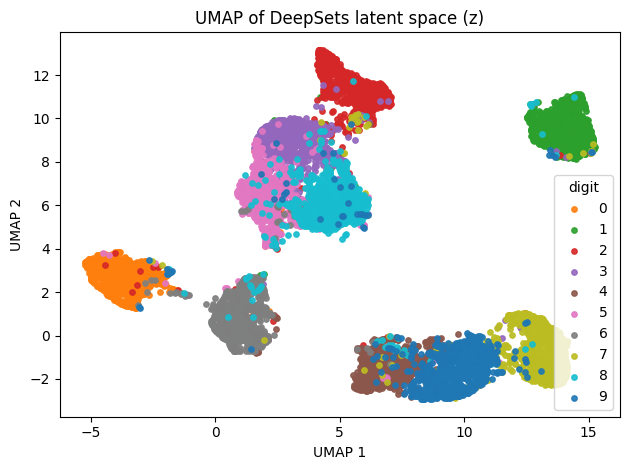

In [264]:
# -------------------------------------------------------------
# RUN THE PIPELINE
# -------------------------------------------------------------
#
# 1. Run a full pass through all sets
# 2. Extract latent vectors z
# 3. Compute PCA
# 4. Visualize clusters
# -------------------------------------------------------------

Z, y = collect_all_sets_z(model_test, test_loader, device)

pca_and_highlight_digits(Z, y)
umap_and_highlight_digits(Z, y)